# BÀI TẬP THỰC HÀNH CHƯƠNG 2
## Biến đổi ảnh

---

## 📁 Cấu trúc thư mục

```
chapter_2_lab/
├── images/              # Ảnh đầu vào
├── output/              # Kết quả xử lý
└── chapter_2_lab.ipynb  # File notebook (đặt trực tiếp ở thư mục ngoài)
```

> File notebook nằm **cùng cấp** với `images/` và `output/`, do đó đường dẫn trong code là `images/...` và `output/...`.

---

## ⚙️ 0. Chuẩn bị môi trường

**Cell 0 — Khởi tạo chung (chạy đầu tiên trong notebook):**

In [1]:
%matplotlib inline

import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from skimage import data

Path("images").mkdir(exist_ok=True)
Path("output").mkdir(exist_ok=True)

print("OpenCV version:", cv2.__version__)
print("NumPy version :", np.__version__)

# ---------- Hàm tiện ích hiển thị ảnh ----------
def show_image(img, title="", cmap=None, figsize=(5, 4), save_path=None):
    """Hiển thị 1 ảnh. Ảnh màu phải ở dạng RGB."""
    plt.figure(figsize=figsize)
    if img.ndim == 3:
        plt.imshow(img)                  # giả định đã ở RGB
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(title)
    plt.axis('off')
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()


def show_grid(images, titles, ncols=3, figsize=(15, 8),
              cmap='gray', save_path=None, main_title=None):
    """Hiển thị nhiều ảnh trong lưới."""
    n = len(images)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).ravel()

    for i, (im, t) in enumerate(zip(images, titles)):
        ax = axes[i]
        if im.ndim == 3:
            ax.imshow(im)
        else:
            ax.imshow(im, cmap=cmap)
        ax.set_title(t, fontsize=10)
        ax.axis('off')

    for j in range(n, len(axes)):
        axes[j].axis('off')

    if main_title:
        plt.suptitle(main_title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()


# ---------- Hàm tiện ích cho miền tần số ----------
def compute_spectrum(img):
    """Trả về phổ biên độ log (đã dịch tâm) của ảnh xám."""
    F = np.fft.fft2(img.astype(np.float32))
    Fshift = np.fft.fftshift(F)
    mag = 20 * np.log(1 + np.abs(Fshift))
    # Chuẩn hóa về [0,255] để hiển thị
    mag_norm = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return Fshift, mag_norm


# ---------- Hàm tạo nhiễu ----------
def add_salt_pepper(img, ratio=0.05):
    """Thêm nhiễu muối tiêu (salt-and-pepper)."""
    noisy = img.copy()
    n = int(ratio * img.size)
    # Muối (trắng)
    coords = [np.random.randint(0, d, n) for d in img.shape]
    noisy[coords[0], coords[1]] = 255
    # Tiêu (đen)
    coords = [np.random.randint(0, d, n) for d in img.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy


def add_gaussian_noise(img, sigma=15):
    """Thêm nhiễu Gaussian."""
    noise = np.random.normal(0, sigma, img.shape)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)


def add_periodic_noise(img, A=30, u0=0.25, v0=0.25):
    """Thêm nhiễu tuần hoàn (dùng cho bài Notch filter)."""
    M, N = img.shape
    x = np.arange(M).reshape(-1, 1)
    y = np.arange(N).reshape(1, -1)
    noise = A * np.sin(2 * np.pi * (u0 * x + v0 * y))
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

OpenCV version: 4.14.0
NumPy version : 2.5.3


> **Lưu ý:** Không dùng `cv2.imshow` / `cv2.waitKey` để tránh treo kernel.

---

## Bài 1: Ảnh âm bản (Image Negative)

**Mức độ:** Cơ bản

**Mục tiêu:** Cài đặt công thức `s = L - 1 - r`.

**Yêu cầu:**
1. Tải ảnh xám `data.camera()`.
2. Tính ảnh âm bản bằng công thức `s = 255 - r`.
3. Hiển thị ảnh gốc và ảnh âm bản cạnh nhau.
4. Lưu kết quả vào `output/bai1_negative.png`.

**Lời giải:**

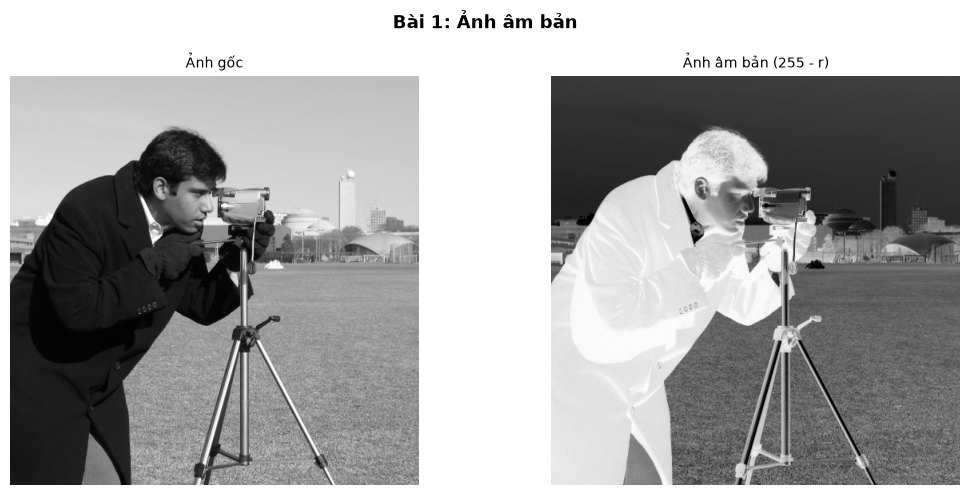

True

In [2]:
img = data.camera()

# 1. Âm bản
negative = 255 - img

# 2. Hiển thị
show_grid(
    [img, negative],
    ['Ảnh gốc', 'Ảnh âm bản (255 - r)'],
    ncols=2, figsize=(11, 5),
    save_path='output/bai1_negative.png',
    main_title='Bài 1: Ảnh âm bản'
)

cv2.imwrite('output/bai1_negative_cv.png', negative)

**📸 Kết quả:** Ảnh âm bản đảo ngược sáng/tối — vùng tối thành sáng và ngược lại, giúp quan sát chi tiết trắng/xám trong vùng tối.

---

## Bài 2: Biến đổi Log

**Mức độ:** Cơ bản

**Mục tiêu:** Cài đặt công thức `s = c · log(1 + r)` để mở rộng vùng tối.

**Yêu cầu:**
1. Tải ảnh `data.camera()`, chuyển sang `float32`.
2. Tính ảnh Log với `c = 255 / log(1 + max(r))`.
3. Hiển thị ảnh gốc + ảnh Log + histogram của cả hai.
4. Lưu kết quả vào `output/bai2_log.png`.

**Lời giải:**

Hệ số c = 45.99


/tmp/ipykernel_68591/1159339400.py:15: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1,0].hist(img.ravel(), 256, [0, 256], color='gray');  axes[1,0].set_title('Histogram gốc')
/tmp/ipykernel_68591/1159339400.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1,1].hist(log_img.ravel(), 256, [0, 256], color='gray'); axes[1,1].set_title('Histogram sau Log')


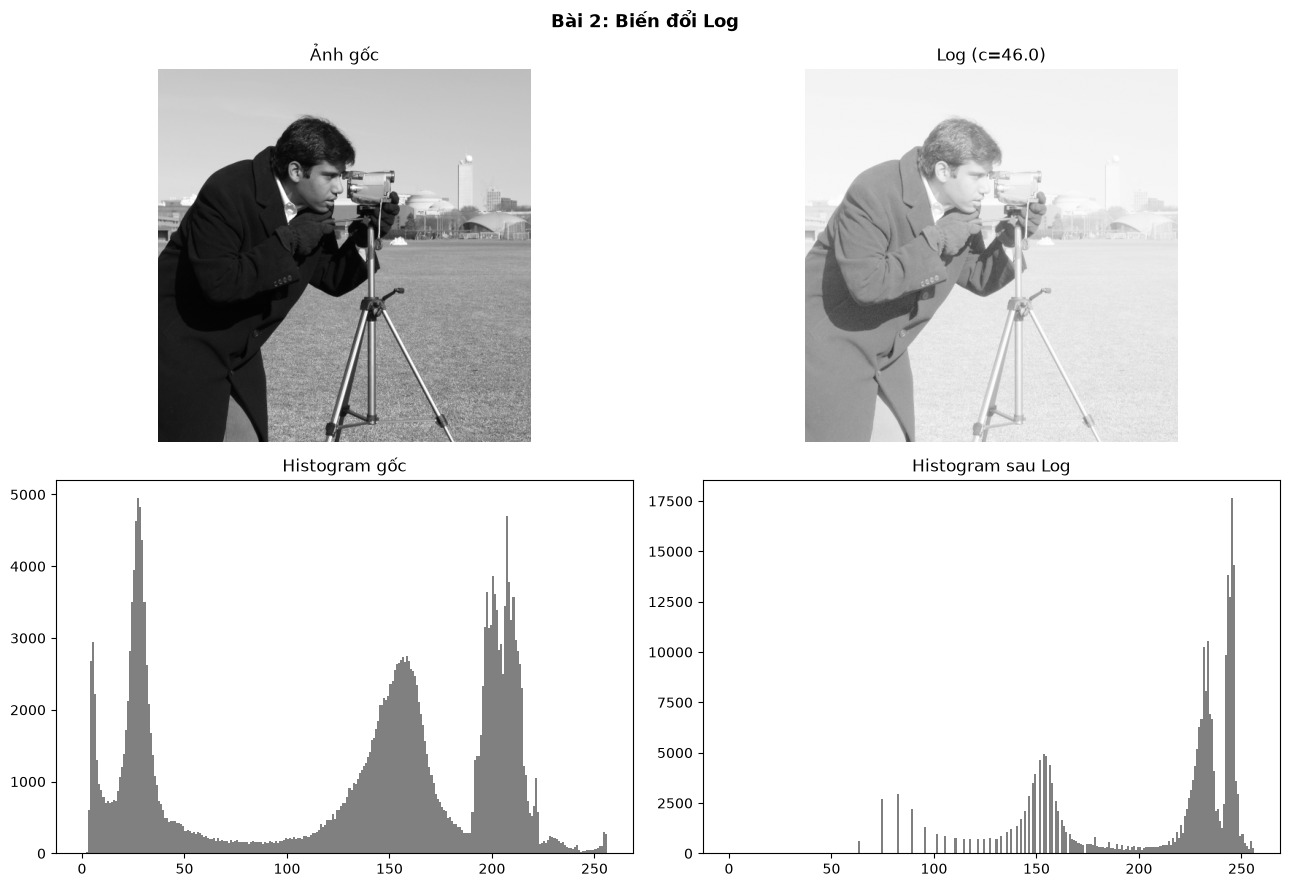

True

In [3]:
img = data.camera().astype(np.float32)

# 1. Hệ số c
c = 255.0 / np.log(1 + img.max())
print(f"Hệ số c = {c:.2f}")

# 2. Biến đổi Log
log_img = c * np.log(1 + img)
log_img = np.clip(log_img, 0, 255).astype(np.uint8)

# 3. Hiển thị ảnh + histogram
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0,0].imshow(img.astype(np.uint8), cmap='gray'); axes[0,0].set_title('Ảnh gốc'); axes[0,0].axis('off')
axes[0,1].imshow(log_img, cmap='gray');                axes[0,1].set_title(f'Log (c={c:.1f})'); axes[0,1].axis('off')
axes[1,0].hist(img.ravel(), 256, [0, 256], color='gray');  axes[1,0].set_title('Histogram gốc')
axes[1,1].hist(log_img.ravel(), 256, [0, 256], color='gray'); axes[1,1].set_title('Histogram sau Log')

plt.suptitle('Bài 2: Biến đổi Log', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/bai2_log.png', dpi=100, bbox_inches='tight')
plt.show()

cv2.imwrite('output/bai2_log_cv.png', log_img)

**📸 Kết quả:** Ảnh sau Log có vùng tối được "nâng sáng" rõ rệt; histogram dịch về phía phải ở vùng giá trị thấp.

---

## Bài 3: Biến đổi Gamma (Power-Law)

**Mức độ:** Cơ bản

**Mục tiêu:** Cài đặt công thức `s = c · r^γ`, quan sát ảnh hưởng của γ.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Áp dụng Gamma với `γ ∈ {0.2, 0.5, 1.0, 2.0, 4.0}` (dùng `cv2.LUT`).
3. Hiển thị 5 kết quả + ảnh gốc trong lưới 2×3.
4. Lưu kết quả vào `output/bai3_gamma.png`.

**Lời giải:**

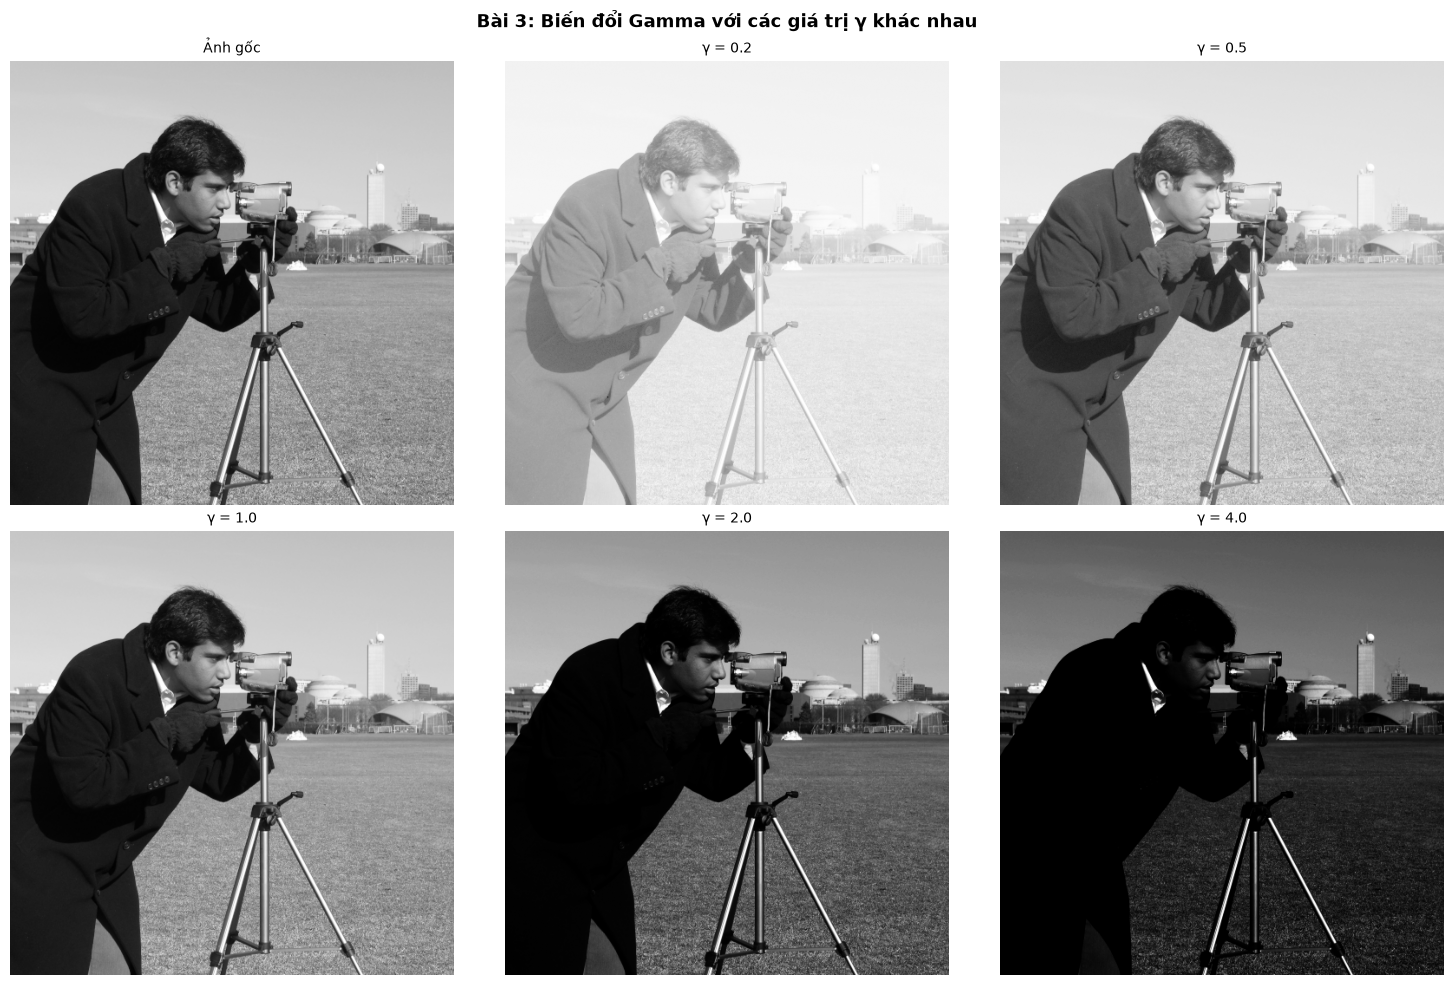

In [4]:
img = data.camera()

def gamma_transform(img, gamma):
    """Biến đổi Gamma dùng LUT để tăng tốc."""
    lut = np.array([
        np.clip(((i / 255.0) ** gamma) * 255.0, 0, 255)
        for i in range(256)
    ]).astype(np.uint8)
    return cv2.LUT(img, lut)

gammas = [0.2, 0.5, 1.0, 2.0, 4.0]
results = [gamma_transform(img, g) for g in gammas]

show_grid(
    [img] + results,
    ['Ảnh gốc'] + [f'γ = {g}' for g in gammas],
    ncols=3, figsize=(15, 10),
    save_path='output/bai3_gamma.png',
    main_title='Bài 3: Biến đổi Gamma với các giá trị γ khác nhau'
)

for g, r in zip(gammas, results):
    cv2.imwrite(f'output/bai3_gamma_{g}.png', r)

**📸 Kết quả:**
- `γ < 1` (0.2, 0.5): ảnh **sáng hơn**, mở rộng vùng tối.
- `γ = 1`: không đổi.
- `γ > 1` (2.0, 4.0): ảnh **tối hơn**, mở rộng vùng sáng.

---

## Bài 4: Biến đổi tuyến tính từng đoạn (Contrast Stretching)

**Mức độ:** Trung bình

**Mục tiêu:** Cài đặt biến đổi piecewise-linear 3 đoạn để tăng độ tương phản.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Cài đặt hàm `contrast_stretch(img, r1, s1, r2, s2)` với công thức:
   - Đoạn 1: `(0,0) → (r1,s1)`
   - Đoạn 2: `(r1,s1) → (r2,s2)` (dốc lớn → tăng tương phản)
   - Đoạn 3: `(r2,s2) → (255,255)`
3. Áp dụng với `(r1,s1,r2,s2) = (70, 0, 180, 255)` và `(100, 0, 150, 255)`.
4. Hiển thị ảnh gốc, 2 kết quả, và histogram tương ứng.
5. Lưu kết quả.

**Lời giải:**

/tmp/ipykernel_68591/90020215.py:25: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1,0].hist(img.ravel(), 256, [0, 256], color='gray'); axes[1,0].set_title('Histogram gốc')
/tmp/ipykernel_68591/90020215.py:26: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1,1].hist(out1.ravel(), 256, [0, 256], color='gray'); axes[1,1].set_title('Histogram out1')
/tmp/ipykernel_68591/90020215.py:27: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1,2].hist(out2.ravel(), 256, [0, 256], color='gray'); axes[1,2].set_title('Histogram out2')


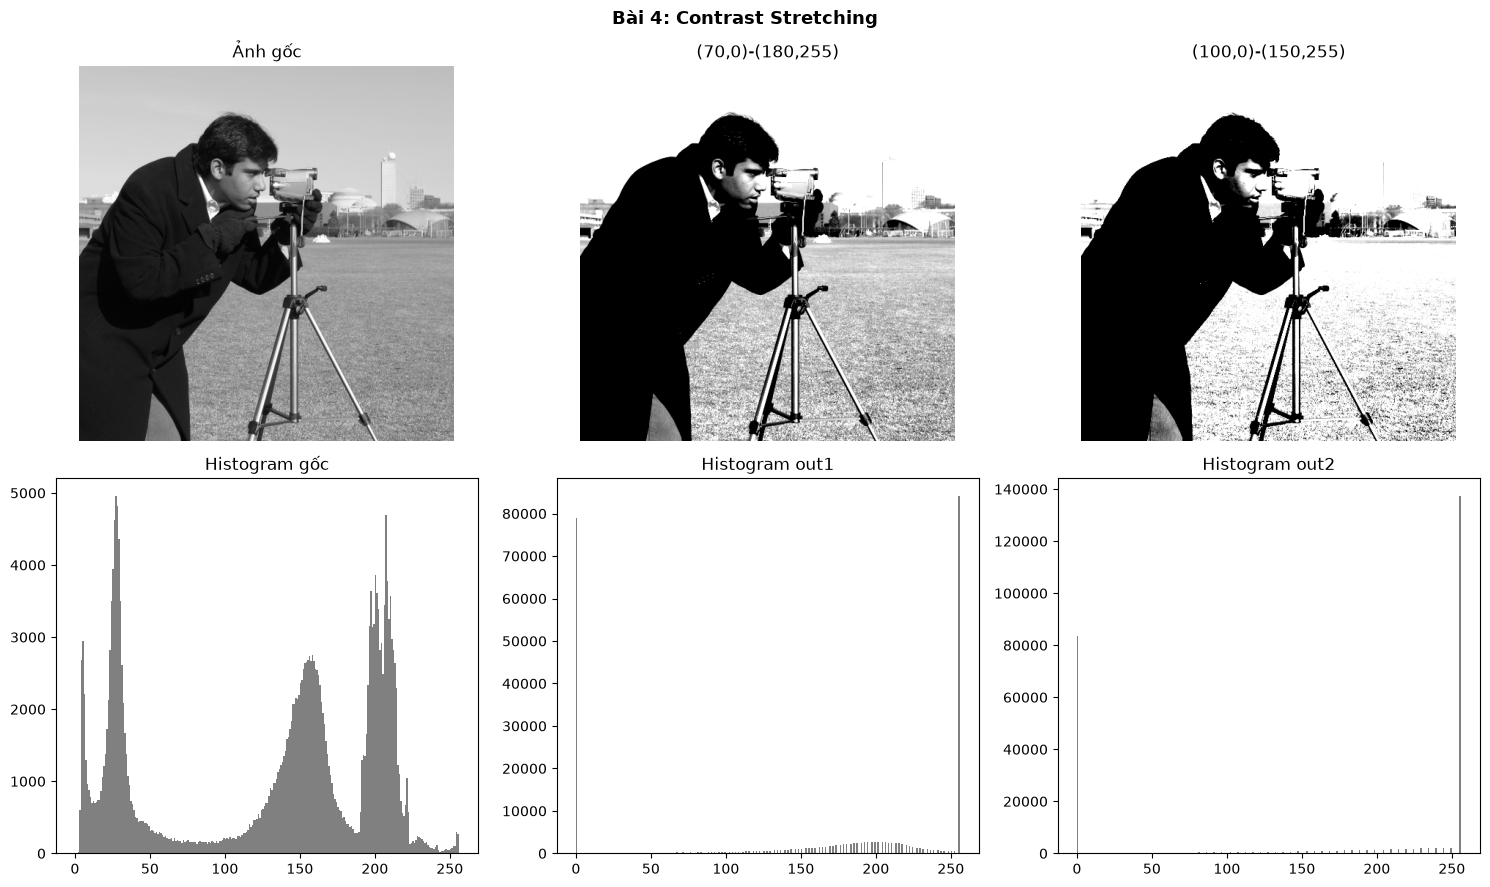

True

In [5]:
img = data.camera()

def contrast_stretch(img, r1, s1, r2, s2):
    """Biến đổi tuyến tính từng đoạn 3 đoạn."""
    L = 256
    lut = np.zeros(256, dtype=np.uint8)
    for r in range(L):
        if r < r1:
            s = s1 * r / r1
        elif r <= r2:
            s = s1 + (s2 - s1) * (r - r1) / (r2 - r1)
        else:
            s = s2 + (L - 1 - s2) * (r - r2) / (L - 1 - r2)
        lut[r] = int(np.clip(s, 0, 255))
    return cv2.LUT(img, lut)

out1 = contrast_stretch(img, 70, 0, 180, 255)
out2 = contrast_stretch(img, 100, 0, 150, 255)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes[0,0].imshow(img, cmap='gray'); axes[0,0].set_title('Ảnh gốc'); axes[0,0].axis('off')
axes[0,1].imshow(out1, cmap='gray'); axes[0,1].set_title('(70,0)-(180,255)'); axes[0,1].axis('off')
axes[0,2].imshow(out2, cmap='gray'); axes[0,2].set_title('(100,0)-(150,255)'); axes[0,2].axis('off')

axes[1,0].hist(img.ravel(), 256, [0, 256], color='gray'); axes[1,0].set_title('Histogram gốc')
axes[1,1].hist(out1.ravel(), 256, [0, 256], color='gray'); axes[1,1].set_title('Histogram out1')
axes[1,2].hist(out2.ravel(), 256, [0, 256], color='gray'); axes[1,2].set_title('Histogram out2')

plt.suptitle('Bài 4: Contrast Stretching', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/bai4_contrast_stretch.png', dpi=100, bbox_inches='tight')
plt.show()

cv2.imwrite('output/bai4_stretch1.png', out1)
cv2.imwrite('output/bai4_stretch2.png', out2)

**📸 Kết quả:** Với đoạn dốc càng lớn (out2), tương phản càng mạnh — histogram dàn trải rộng hơn.

---

## Bài 5: Cắt mức xám (Gray-Level Slicing)

**Mức độ:** Trung bình

**Mục tiêu:** Làm nổi bật một dải mức xám cụ thể — ứng dụng trong ảnh y tế.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Cài đặt 2 biến thể:
   - **Binary slicing:** pixel trong `[a, b]` → 255, ngoài → 0.
   - **Preserve slicing:** pixel trong `[a, b]` → 255, ngoài → giữ nguyên ảnh gốc.
3. Áp dụng với dải `[100, 150]`.
4. Hiển thị và lưu kết quả.

**Lời giải:**

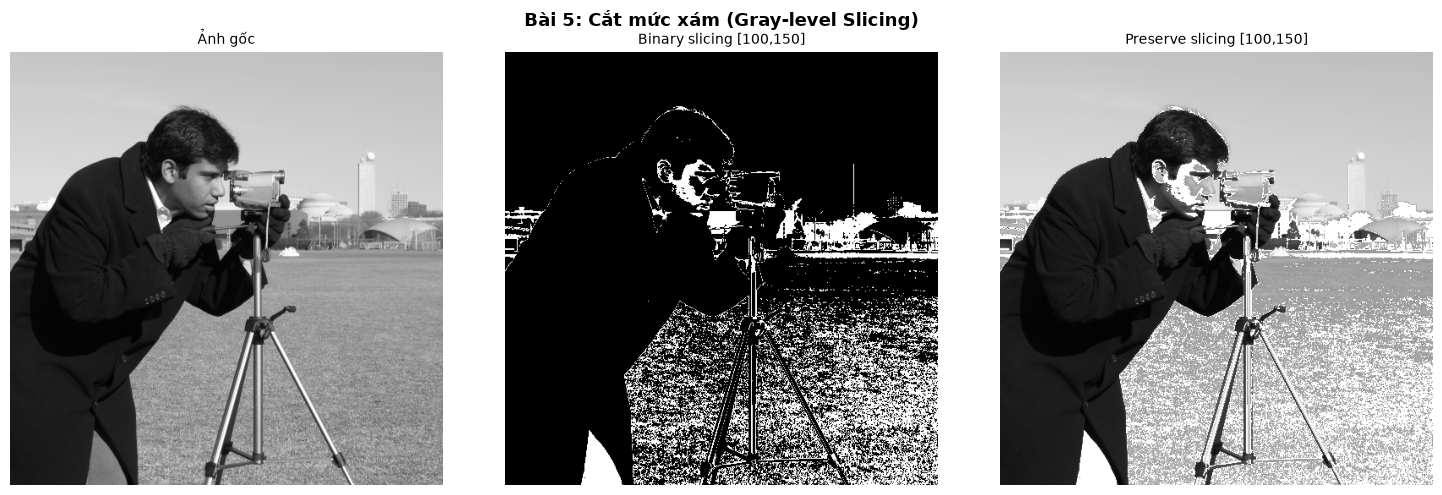

True

In [6]:
img = data.camera()
a, b = 100, 150

# 1. Binary slicing
binary_slice = np.where((img >= a) & (img <= b), 255, 0).astype(np.uint8)

# 2. Preserve slicing
preserve_slice = img.copy()
preserve_slice[(img >= a) & (img <= b)] = 255

show_grid(
    [img, binary_slice, preserve_slice],
    ['Ảnh gốc',
     f'Binary slicing [{a},{b}]',
     f'Preserve slicing [{a},{b}]'],
    ncols=3, figsize=(15, 5),
    save_path='output/bai5_gray_slicing.png',
    main_title='Bài 5: Cắt mức xám (Gray-level Slicing)'
)

cv2.imwrite('output/bai5_binary.png',   binary_slice)
cv2.imwrite('output/bai5_preserve.png', preserve_slice)

**📸 Kết quả:** Binary chỉ giữ pixel trong dải; Preserve làm nổi bật dải nhưng vẫn giữ nền.

---

## Bài 6: Trích xuất Bit-Plane

**Mức độ:** Trung bình

**Mục tiêu:** Phân tích đóng góp của từng bit trong byte biểu diễn pixel.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Trích xuất 8 bit-plane: `plane_b = (img >> b) & 1`, nhân 255 để hiển thị.
3. Hiển thị cả 8 plane trong lưới 2×4.
4. Lưu các bit-plane quan trọng (bit 7 và bit 6) vào `output/`.

**Lời giải:**

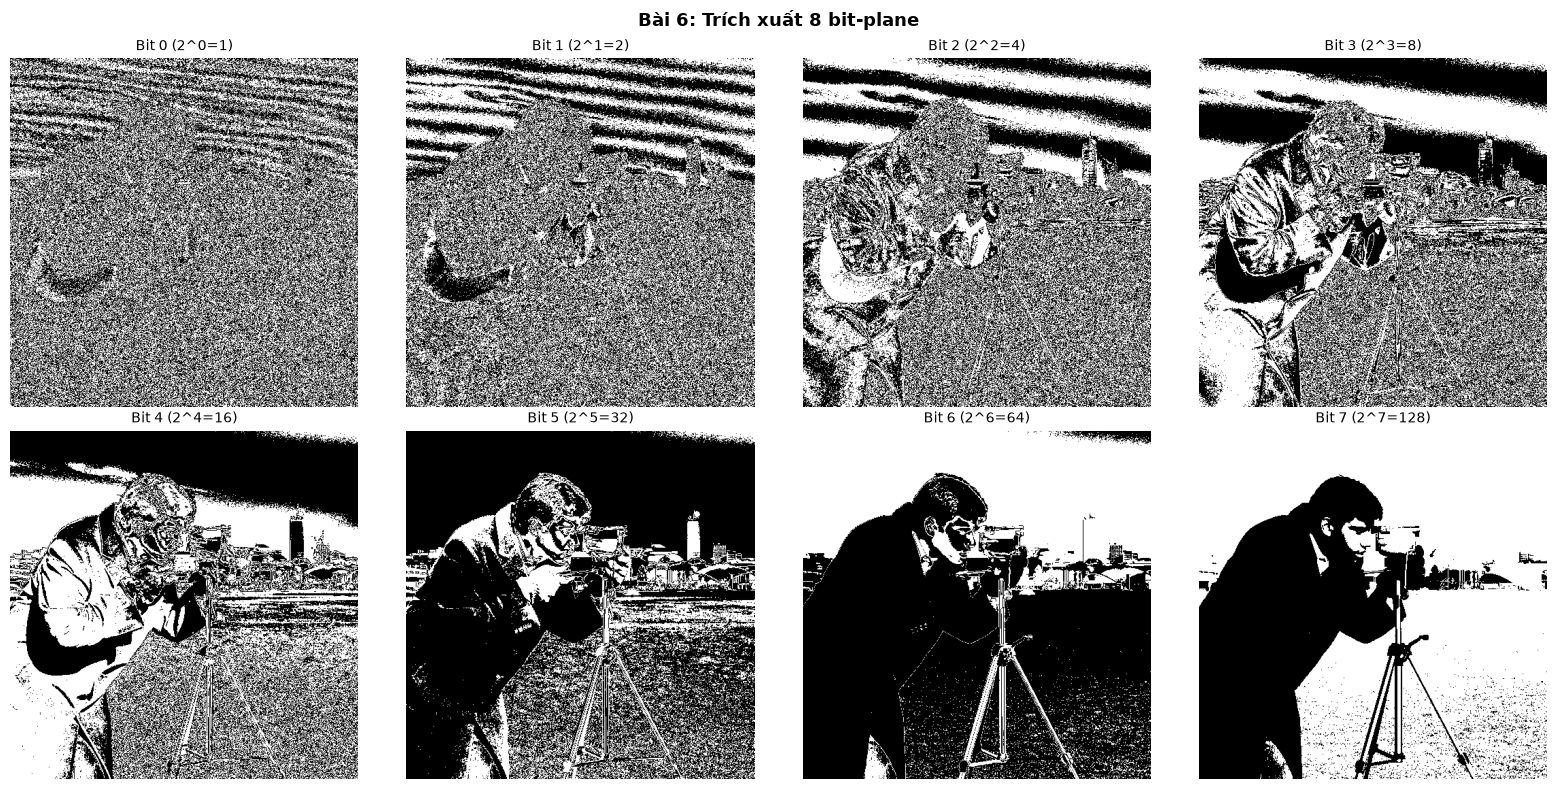

True

In [7]:
img = data.camera()

planes = []
titles = []
for b in range(8):
    plane = ((img >> b) & 1) * 255
    planes.append(plane.astype(np.uint8))
    titles.append(f'Bit {b} (2^{b}={2**b})')

show_grid(
    planes, titles,
    ncols=4, figsize=(16, 8),
    save_path='output/bai6_bit_planes.png',
    main_title='Bài 6: Trích xuất 8 bit-plane'
)

cv2.imwrite('output/bai6_bit7.png', planes[7])
cv2.imwrite('output/bai6_bit6.png', planes[6])

**📸 Kết quả:**
- **Bit 7 (MSB):** mang phần lớn thông tin ảnh (cấu trúc chính).
- **Bit 0 (LSB):** chủ yếu là nhiễu, ít thông tin.

---

## Bài 7: Lọc trung bình (Mean Filter) — cài đặt thủ công

**Mức độ:** Trung bình

**Mục tiêu:** Hiểu cơ chế convolution bằng cách tự cài đặt kernel 3×3 và so sánh với OpenCV.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Cài đặt thủ công hàm `mean_filter_manual(img, ksize)` dùng vòng lặp (chỉ chạy với ảnh nhỏ cắt ra để minh họa).
3. So sánh với `cv2.blur(img, (ksize, ksize))` và `cv2.filter2D`.
4. Áp dụng kernel 3×3, 5×5, 9×9 lên ảnh gốc, hiển thị kết quả.
5. Lưu kết quả.

**Lời giải:**

Sai số tuyệt đối trung bình (manual vs cv2.blur): 0.433


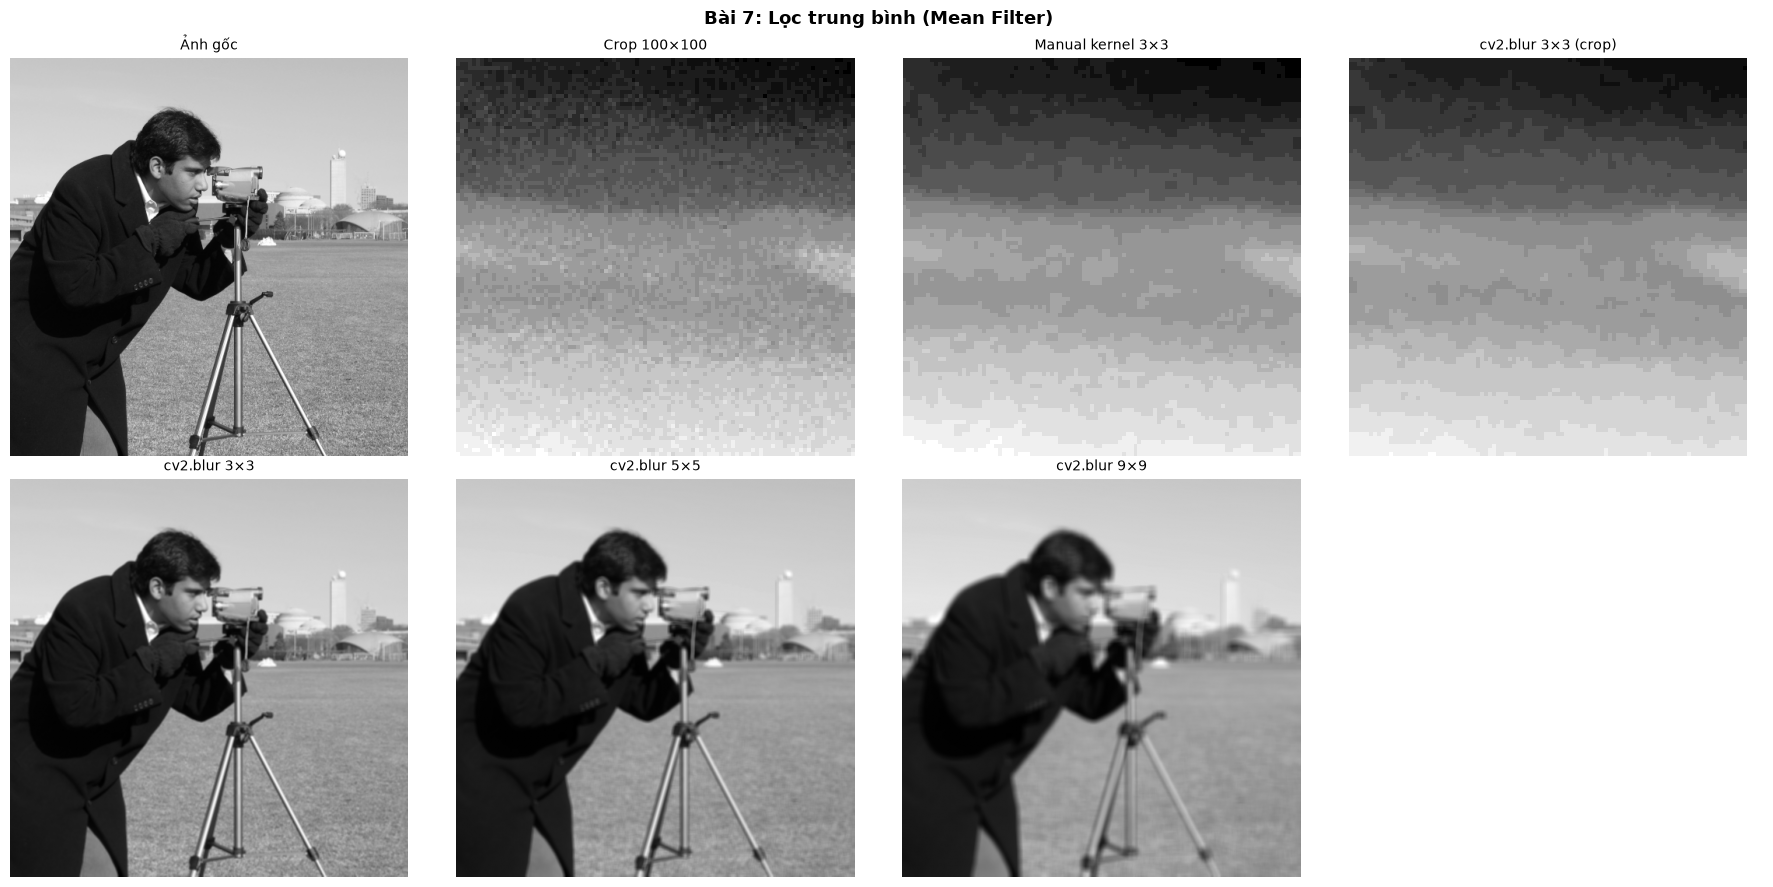

True

In [8]:
img = data.camera()

def mean_filter_manual(img, ksize=3):
    """Cài đặt lọc trung bình bằng vòng lặp (chỉ dùng cho ảnh nhỏ)."""
    k = ksize // 2
    h, w = img.shape
    out = np.zeros_like(img, dtype=np.float32)
    padded = np.pad(img.astype(np.float32), k, mode='edge')
    for i in range(h):
        for j in range(w):
            out[i, j] = padded[i:i+ksize, j:j+ksize].mean()
    return np.clip(out, 0, 255).astype(np.uint8)

# So sánh manual vs cv2 trên ảnh nhỏ 100×100 để không quá chậm
small = img[:100, :100]
manual_3 = mean_filter_manual(small, 3)
cv2_blur_3 = cv2.blur(small, (3, 3))

print("Sai số tuyệt đối trung bình (manual vs cv2.blur):",
      np.mean(np.abs(manual_3.astype(int) - cv2_blur_3.astype(int))))

# Áp dụng trên ảnh đầy đủ
mean_3 = cv2.blur(img, (3, 3))
mean_5 = cv2.blur(img, (5, 5))
mean_9 = cv2.blur(img, (9, 9))

show_grid(
    [img, small, manual_3, cv2_blur_3, mean_3, mean_5, mean_9],
    ['Ảnh gốc',
     'Crop 100×100',
     'Manual kernel 3×3',
     'cv2.blur 3×3 (crop)',
     'cv2.blur 3×3',
     'cv2.blur 5×5',
     'cv2.blur 9×9'],
    ncols=4, figsize=(18, 9),
    save_path='output/bai7_mean_filter.png',
    main_title='Bài 7: Lọc trung bình (Mean Filter)'
)

cv2.imwrite('output/bai7_mean_3.png', mean_3)
cv2.imwrite('output/bai7_mean_9.png', mean_9)

**📸 Kết quả:** Kernel càng lớn → ảnh càng mờ; manual và `cv2.blur` cho kết quả gần như giống hệt.

---

## Bài 8: Lọc Gaussian

**Mức độ:** Trung bình

**Mục tiêu:** Hiểu tác dụng của σ (độ lệch chuẩn) trong kernel Gaussian.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Áp dụng `cv2.GaussianBlur` với 3 cặp tham số:
   - `ksize=5, sigma=1`
   - `ksize=5, sigma=5`
   - `ksize=15, sigma=5`
3. So sánh với lọc trung bình `cv2.blur(5×5)`.
4. Hiển thị và lưu kết quả.

**Lời giải:**

In [ ]:
img = data.camera()

g1 = cv2.GaussianBlur(img, (5, 5),  sigmaX=1)
g2 = cv2.GaussianBlur(img, (5, 5),  sigmaX=5)
g3 = cv2.GaussianBlur(img, (15, 15), sigmaX=5)
mean5 = cv2.blur(img, (5, 5))

show_grid(
    [img, mean5, g1, g2, g3],
    ['Ảnh gốc',
     'Mean 5×5',
     'Gaussian k=5, σ=1',
     'Gaussian k=5, σ=5',
     'Gaussian k=15, σ=5'],
    ncols=3, figsize=(15, 10),
    save_path='output/bai8_gaussian.png',
    main_title='Bài 8: Lọc Gaussian vs Lọc trung bình'
)

cv2.imwrite('output/bai8_gauss_s1.png', g1)
cv2.imwrite('output/bai8_gauss_s5.png', g2)

**📸 Kết quả:** Gaussian mượt tự nhiên hơn Mean, ít để lại hiệu ứng "khối vuông"; σ càng lớn → mờ càng mạnh.

---

## Bài 9: Lọc trung vị — Khử nhiễu muối tiêu

**Mức độ:** Trung bình

**Mục tiêu:** Minh họa sức mạnh của Median filter với nhiễu salt-and-pepper.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Thêm nhiễu muối tiêu tỉ lệ 5% và 10%.
3. Khử nhiễu bằng `cv2.medianBlur` (k=3, 5) và so sánh với `cv2.blur` (mean 3×3).
4. Tính MSE giữa ảnh khử nhiễu và ảnh gốc cho từng phương pháp.
5. Hiển thị và lưu kết quả.

**Lời giải:**

In [ ]:
img = data.camera()

def add_salt_pepper(img, ratio=0.05):
    noisy = img.copy()
    n = int(ratio * img.size)
    coords = [np.random.randint(0, d, n) for d in img.shape]
    noisy[coords[0], coords[1]] = 255
    coords = [np.random.randint(0, d, n) for d in img.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy

noisy_5  = add_salt_pepper(img, 0.05)
noisy_10 = add_salt_pepper(img, 0.10)

med3 = cv2.medianBlur(noisy_5, 3)
med5 = cv2.medianBlur(noisy_5, 5)
mean3 = cv2.blur(noisy_5, (3, 3))

def mse(a, b):
    return np.mean((a.astype(np.float32) - b.astype(np.float32)) ** 2)

print(f"MSE (đối với ảnh gốc):")
print(f"  Nhiễu 5%           : {mse(img, noisy_5):.2f}")
print(f"  Median 3×3         : {mse(img, med3):.2f}")
print(f"  Median 5×5         : {mse(img, med5):.2f}")
print(f"  Mean 3×3           : {mse(img, mean3):.2f}")

show_grid(
    [img, noisy_5, noisy_10, med3, med5, mean3],
    ['Ảnh gốc',
     'Nhiễu S&P 5%',
     'Nhiễu S&P 10%',
     'Median 3×3',
     'Median 5×5',
     'Mean 3×3 (kém hiệu quả)'],
    ncols=3, figsize=(15, 10),
    save_path='output/bai9_median.png',
    main_title='Bài 9: Lọc trung vị khử nhiễu muối tiêu'
)

cv2.imwrite('output/bai9_noisy.png', noisy_5)
cv2.imwrite('output/bai9_med3.png',  med3)

**📸 Kết quả:** Median khử muối tiêu cực tốt và giữ biên sắc nét; Mean chỉ làm mờ nhiễu chứ không khử được.

---

## Bài 10: Bộ lọc Laplacian — Làm nét ảnh

**Mức độ:** Trung bình

**Mục tiêu:** Làm nét ảnh bằng Laplacian theo công thức `g = f - k·∇²f`.

**Yêu cầu:**
1. Tải ảnh `data.camera()` (hoặc `data.moon()`).
2. Tính `Laplacian` bằng `cv2.Laplacian(img, cv2.CV_64F)`.
3. Làm nét ảnh gốc: `g = img - k * laplacian` với `k ∈ {0.5, 1.0, 2.0}`.
4. Hiển thị ảnh gốc, ảnh Laplace, và 3 ảnh làm nét.
5. Lưu kết quả.

**Lời giải:**

In [ ]:
img = data.camera()

# 1. Laplace
laplacian = cv2.Laplacian(img, cv2.CV_64F)

# 2. Làm nét với các hệ số k khác nhau
def sharpen(img, laplacian, k):
    g = img.astype(np.float64) - k * laplacian
    return np.clip(g, 0, 255).astype(np.uint8)

sharp_05 = sharpen(img, laplacian, 0.5)
sharp_10 = sharpen(img, laplacian, 1.0)
sharp_20 = sharpen(img, laplacian, 2.0)

# Hiển thị (Laplacian cần chuẩn hóa để xem)
lap_vis = cv2.normalize(np.abs(laplacian), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

show_grid(
    [img, lap_vis, sharp_05, sharp_10, sharp_20],
    ['Ảnh gốc',
     '|Laplacian| (chuẩn hóa)',
     'Làm nét k=0.5',
     'Làm nét k=1.0',
     'Làm nét k=2.0 (quá mức)'],
    ncols=3, figsize=(15, 10),
    save_path='output/bai10_laplacian.png',
    main_title='Bài 10: Làm nét ảnh với bộ lọc Laplacian'
)

cv2.imwrite('output/bai10_laplacian_raw.png', lap_vis)
cv2.imwrite('output/bai10_sharp_k1.png', sharp_10)

**📸 Kết quả:** `|Laplacian|` là ảnh biên (đường viền mảnh). Ảnh làm nét với k=1.0 nổi bật chi tiết; k=2.0 bắt đầu xuất hiện nhiễu và quầng sáng.

---

## Bài 11: Bộ lọc Sobel — Gradient và phát hiện biên

**Mức độ:** Trung bình

**Mục tiêu:** Tính đạo hàm theo 2 hướng và độ lớn gradient.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Tính `Gx`, `Gy` bằng `cv2.Sobel` (kernel 3×3, `CV_64F`).
3. Tính độ lớn gradient: `M = sqrt(Gx² + Gy²)` và xấp xỉ `|Gx| + |Gy|`.
4. Hiển thị ảnh gốc, Gx, Gy, M, xấp xỉ M.
5. Lưu kết quả.

**Lời giải:**

In [ ]:
img = data.camera()

Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

M_exact = np.sqrt(Gx**2 + Gy**2)
M_approx = np.abs(Gx) + np.abs(Gy)

# Chuẩn hóa để hiển thị
def norm_vis(x):
    return cv2.normalize(np.abs(x), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

print(f"Sai số tuyệt đối trung bình giữa M_exact và M_approx: "
      f"{np.mean(np.abs(M_exact - M_approx)):.2f}")

show_grid(
    [img, norm_vis(Gx), norm_vis(Gy), norm_vis(M_exact), norm_vis(M_approx)],
    ['Ảnh gốc',
     '|Gx| (đạo hàm ngang)',
     '|Gy| (đạo hàm dọc)',
     'M = √(Gx²+Gy²)',
     'M ≈ |Gx|+|Gy|'],
    ncols=3, figsize=(15, 10),
    save_path='output/bai11_sobel.png',
    main_title='Bài 11: Phát hiện biên với bộ lọc Sobel'
)

cv2.imwrite('output/bai11_sobelx.png', norm_vis(Gx))
cv2.imwrite('output/bai11_sobely.png', norm_vis(Gy))
cv2.imwrite('output/bai11_magnitude.png', norm_vis(M_exact))

**📸 Kết quả:** Gx làm nổi bật biên **dọc** (thay đổi theo hướng x); Gy làm nổi bật biên **ngang**; M làm nổi bật **tất cả** biên.

---

## Bài 12: Unsharp Masking & Highboost Filtering

**Mức độ:** Nâng cao

**Mục tiêu:** Cài đặt công thức `g = f + k·(f - f_blur)`.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Làm mờ bằng Gaussian σ=2, ksize=5×5 để được `f_blur`.
3. Tính mask `m = f - f_blur`.
4. Tạo ảnh:
   - **Unsharp Masking** (k=1): `g = f + 1·m`.
   - **Highboost** với k = 1.5, 2.5.
5. Hiển thị ảnh gốc, mask (chuẩn hóa), và 3 kết quả.
6. Lưu kết quả.

**Lời giải:**

In [ ]:
img = data.camera()

# 1. Làm mờ
f_blur = cv2.GaussianBlur(img, (5, 5), sigmaX=2)

# 2. Mask = f - f_blur
mask = img.astype(np.float32) - f_blur.astype(np.float32)

# 3. Unsharp + Highboost
def highboost(img, mask, k):
    g = img.astype(np.float32) + k * mask
    return np.clip(g, 0, 255).astype(np.uint8)

usm   = highboost(img, mask, 1.0)   # unsharp
hb_15 = highboost(img, mask, 1.5)   # highboost
hb_25 = highboost(img, mask, 2.5)   # highboost mạnh

# Hiển thị
mask_vis = cv2.normalize(mask, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

show_grid(
    [img, f_blur, mask_vis, usm, hb_15, hb_25],
    ['Ảnh gốc',
     'Làm mờ f_blur (Gaussian)',
     'Mask (f - f_blur)',
     'Unsharp (k=1.0)',
     'Highboost (k=1.5)',
     'Highboost (k=2.5)'],
    ncols=3, figsize=(15, 10),
    save_path='output/bai12_unsharp.png',
    main_title='Bài 12: Unsharp Masking & Highboost Filtering'
)

cv2.imwrite('output/bai12_usm.png',   usm)
cv2.imwrite('output/bai12_hb_15.png', hb_15)

**📸 Kết quả:** k=1.0 làm nét tự nhiên; k=2.5 làm nét mạnh nhưng xuất hiện quầng sáng (halo) quanh biên.

---

## Bài 13: Histogram và Cân bằng Histogram

**Mức độ:** Trung bình

**Mục tiêu:** Áp dụng `cv2.equalizeHist` để tăng tương phản toàn cục.

**Yêu cầu:**
1. Tải ảnh `data.camera()` — có thể thử thêm một ảnh tối (ví dụ `img // 2`).
2. Áp dụng `cv2.equalizeHist`.
3. Hiển thị ảnh + histogram trước và sau cân bằng.
4. Lưu kết quả.

**Lời giải:**

In [ ]:
img = data.camera()

# Tạo ảnh tối để minh họa rõ hiệu quả
dark_img = (img.astype(np.float32) * 0.4).astype(np.uint8)

eq_dark = cv2.equalizeHist(dark_img)
eq_normal = cv2.equalizeHist(img)

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
axes[0,0].imshow(dark_img, cmap='gray'); axes[0,0].set_title('Ảnh tối (×0.4)'); axes[0,0].axis('off')
axes[0,1].hist(dark_img.ravel(), 256, [0, 256], color='gray'); axes[0,1].set_title('Histogram ảnh tối')
axes[1,0].imshow(eq_dark, cmap='gray'); axes[1,0].set_title('Sau cân bằng (ảnh tối)'); axes[1,0].axis('off')
axes[1,1].hist(eq_dark.ravel(), 256, [0, 256], color='gray'); axes[1,1].set_title('Histogram sau cân bằng')
axes[2,0].imshow(img, cmap='gray'); axes[2,0].set_title('Ảnh gốc'); axes[2,0].axis('off')
axes[2,1].imshow(eq_normal, cmap='gray'); axes[2,1].set_title('Cân bằng (ảnh gốc)'); axes[2,1].axis('off')

plt.suptitle('Bài 13: Cân bằng Histogram', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/bai13_equalization.png', dpi=100, bbox_inches='tight')
plt.show()

cv2.imwrite('output/bai13_eq_dark.png',   eq_dark)
cv2.imwrite('output/bai13_eq_normal.png', eq_normal)

**📸 Kết quả:** Ảnh tối sau cân bằng có tương phản tăng rõ rệt, histogram dàn trải đều hơn.

---

## Bài 14: Khớp Histogram (Histogram Matching)

**Mức độ:** Nâng cao

**Mục tiêu:** Cài đặt thuật toán khớp histogram theo mẫu chỉ định.

**Yêu cầu:**
1. Dùng 2 ảnh `data.camera()` (source) và `data.moon()` (template).
2. Cài đặt hàm `histogram_matching(source, template)`:
   - Tính CDF của source và template.
   - Với mỗi mức xám `i` của source, tìm `j` trong template sao cho `CDF_template(j) ≥ CDF_source(i)`.
3. Hiển thị ảnh source, template, ảnh matched + 3 histogram tương ứng.
4. Lưu kết quả.

**Lời giải:**

In [ ]:
source   = data.camera()
template = data.moon()

def histogram_matching(source, template):
    src_hist, _  = np.histogram(source.flatten(),   256, [0, 256])
    tmpl_hist, _ = np.histogram(template.flatten(), 256, [0, 256])

    src_cdf  = np.cumsum(src_hist).astype(np.float64);  src_cdf  /= src_cdf[-1]
    tmpl_cdf = np.cumsum(tmpl_hist).astype(np.float64); tmpl_cdf /= tmpl_cdf[-1]

    # Với mỗi i của source -> tìm j nhỏ nhất sao cho tmpl_cdf[j] >= src_cdf[i]
    mapping = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        j = np.searchsorted(tmpl_cdf, src_cdf[i])
        mapping[i] = min(j, 255)

    return mapping[source]

matched = histogram_matching(source, template)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes[0,0].imshow(source, cmap='gray'); axes[0,0].set_title('Source (camera)'); axes[0,0].axis('off')
axes[0,1].imshow(template, cmap='gray'); axes[0,1].set_title('Template (moon)'); axes[0,1].axis('off')
axes[0,2].imshow(matched, cmap='gray'); axes[0,2].set_title('Matched'); axes[0,2].axis('off')

axes[1,0].hist(source.ravel(), 256, [0, 256], color='gray'); axes[1,0].set_title('Histogram source')
axes[1,1].hist(template.ravel(), 256, [0, 256], color='gray'); axes[1,1].set_title('Histogram template')
axes[1,2].hist(matched.ravel(), 256, [0, 256], color='gray'); axes[1,2].set_title('Histogram matched')

plt.suptitle('Bài 14: Khớp Histogram', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output/bai14_hist_matching.png', dpi=100, bbox_inches='tight')
plt.show()

cv2.imwrite('output/bai14_matched.png', matched)

**📸 Kết quả:** Histogram của ảnh matched gần khớp với histogram template; ảnh matched có tông sáng/tối giống template.

---

## Bài 15: Biến đổi Fourier — Phổ tần số

**Mức độ:** Nâng cao

**Mục tiêu:** Hiểu ý nghĩa của phổ Fourier, tính chất dịch chuyển và đối xứng.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Tính FFT bằng `np.fft.fft2`, dịch tâm bằng `np.fft.fftshift`.
3. Hiển thị phổ biên độ log: `20·log(1 + |F|)`.
4. Chứng minh tính dịch chuyển: dịch ảnh đi `(50, 50)` — phổ **không đổi** về biên độ.
5. Hiển thị và lưu kết quả.

**Lời giải:**

In [ ]:
img = data.camera()

# FFT ảnh gốc
F = np.fft.fft2(img.astype(np.float32))
Fshift = np.fft.fftshift(F)
mag_orig = 20 * np.log(1 + np.abs(Fshift))

# Dịch ảnh đi (50, 50) bằng cách roll
img_shifted = np.roll(np.roll(img, 50, axis=0), 50, axis=1)
F2 = np.fft.fft2(img_shifted.astype(np.float32))
Fshift2 = np.fft.fftshift(F2)
mag_shift = 20 * np.log(1 + np.abs(Fshift2))

# Chuẩn hóa để hiển thị
def norm_vis(x):
    return cv2.normalize(x, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

print(f"Sai số tuyệt đối trung bình giữa 2 phổ biên độ: "
      f"{np.mean(np.abs(np.abs(Fshift) - np.abs(Fshift2))):.4e}")

show_grid(
    [img, img_shifted, norm_vis(mag_orig), norm_vis(mag_shift)],
    ['Ảnh gốc',
     'Ảnh dịch (50, 50)',
     'Phổ biên độ (ảnh gốc)',
     'Phổ biên độ (ảnh dịch)'],
    ncols=2, figsize=(13, 10),
    save_path='output/bai15_fft.png',
    main_title='Bài 15: Biến đổi Fourier — Phổ tần số'
)

cv2.imwrite('output/bai15_spectrum.png', norm_vis(mag_orig))

**📸 Kết quả:**
- Tâm phổ rất sáng → thành phần DC (độ sáng trung bình).
- Càng xa tâm → tần số càng cao (biên, chi tiết).
- Dịch chuyển trong không gian **không** làm thay đổi phổ biên độ → xác nhận tính chất Translation.

---

## Bài 16: Lọc thông thấp trong miền tần số (Ideal & Gaussian LPF)

**Mức độ:** Nâng cao

**Mục tiêu:** Cài đặt LPF trong miền tần số và so sánh ILPF với GLPF.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Cài đặt hàm `ideal_lpf(shape, D0)` và `gaussian_lpf(shape, D0)`.
3. Áp dụng với `D0 ∈ {10, 30, 60}` cho cả 2 loại.
4. Biến đổi ngược và hiển thị.
5. So sánh hiện tượng ringing của ILPF.
6. Lưu kết quả.

**Lời giải:**

In [ ]:
img = data.camera()
M, N = img.shape
crow, ccol = M // 2, N // 2

def ideal_lpf(shape, D0):
    M, N = shape
    u = np.arange(M).reshape(-1, 1) - M // 2
    v = np.arange(N).reshape(1, -1) - N // 2
    D = np.sqrt(u**2 + v**2)
    return (D <= D0).astype(np.float32)

def gaussian_lpf(shape, D0):
    M, N = shape
    u = np.arange(M).reshape(-1, 1) - M // 2
    v = np.arange(N).reshape(1, -1) - N // 2
    D2 = u**2 + v**2
    return np.exp(-D2 / (2 * D0**2)).astype(np.float32)

def apply_filter(img, H):
    F = np.fft.fft2(img.astype(np.float32))
    Fshift = np.fft.fftshift(F)
    G = Fshift * H
    g = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))
    return np.clip(g, 0, 255).astype(np.uint8)

D0_list = [10, 30, 60]
ideal_imgs = [apply_filter(img, ideal_lpf(img.shape, D0)) for D0 in D0_list]
gauss_imgs = [apply_filter(img, gaussian_lpf(img.shape, D0)) for D0 in D0_list]

show_grid(
    [img] + ideal_imgs + gauss_imgs,
    ['Ảnh gốc'] +
    [f'ILPF D0={d}' for d in D0_list] +
    [f'GLPF D0={d}' for d in D0_list],
    ncols=4, figsize=(18, 10),
    save_path='output/bai16_lpf.png',
    main_title='Bài 16: Lọc thông thấp — ILPF (hàng trên) vs GLPF (hàng dưới)'
)

for D0, im in zip(D0_list, ideal_imgs):
    cv2.imwrite(f'output/bai16_ilpf_{D0}.png', im)
for D0, im in zip(D0_list, gauss_imgs):
    cv2.imwrite(f'output/bai16_glpf_{D0}.png', im)

**📸 Kết quả:** ILPF gây **ringing** rõ (các vòng sáng/tối quanh biên). GLPF mượt hơn, không ringing.

---

## Bài 17: Lọc thông cao & High-Frequency Emphasis

**Mức độ:** Nâng cao

**Mục tiêu:** Cài đặt HPF và giải quyết vấn đề ảnh bị tối bằng High-frequency Emphasis.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Tính `H_HP = 1 - H_LP` (Gaussian).
3. Áp dụng HPF với `D0 = 30` — quan sát ảnh bị tối mất độ sáng tổng thể.
4. Cài đặt High-frequency Emphasis: `H = a + b·H_HP` với `(a, b) = (0.5, 2.0)`.
5. Hiển thị và lưu kết quả.

**Lời giải:**

In [ ]:
img = data.camera()

def gaussian_lpf(shape, D0):
    M, N = shape
    u = np.arange(M).reshape(-1, 1) - M // 2
    v = np.arange(N).reshape(1, -1) - N // 2
    D2 = u**2 + v**2
    return np.exp(-D2 / (2 * D0**2)).astype(np.float32)

def apply_filter(img, H):
    F = np.fft.fft2(img.astype(np.float32))
    Fshift = np.fft.fftshift(F)
    G = Fshift * H
    g = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))
    return np.clip(g, 0, 255).astype(np.uint8)

D0 = 30
H_LP = gaussian_lpf(img.shape, D0)
H_HP = 1.0 - H_LP

# HPF thuần
img_hp = apply_filter(img, H_HP)

# High-frequency emphasis
a, b = 0.5, 2.0
H_he = a + b * H_HP
img_he = apply_filter(img, H_he)

show_grid(
    [img, img_hp, img_he],
    ['Ảnh gốc',
     'HPF thuần (D0=30)\n→ tối, mất độ sáng tổng thể',
     f'High-freq Emphasis (a={a}, b={b})\n→ giữ nền, làm nét'],
    ncols=3, figsize=(15, 5),
    save_path='output/bai17_hpf.png',
    main_title='Bài 17: Lọc thông cao & High-Frequency Emphasis'
)

cv2.imwrite('output/bai17_hpf.png',       img_hp)
cv2.imwrite('output/bai17_emphasis.png',  img_he)

**📸 Kết quả:** HPF thuần cho ảnh **tối đen**, chỉ giữ biên. High-frequency Emphasis giữ lại độ sáng nền nhưng vẫn làm nét biên.

---

## Bài 18: Lọc Notch — Khử nhiễu tuần hoàn

**Mức độ:** Nâng cao

**Mục tiêu:** Loại bỏ nhiễu tuần hoàn (định kỳ) bằng bộ lọc Notch trong miền tần số.

**Yêu cầu:**
1. Tải ảnh `data.camera()`.
2. Thêm nhiễu tuần hoàn sin (nhiễu định kỳ) tạo các **đỉnh sáng** trên phổ.
3. Xác định vị trí đỉnh nhiễu trên phổ.
4. Cài đặt notch filter: đặt giá trị 0 tại các đỉnh nhiễu (và đối xứng của chúng).
5. Biến đổi ngược, hiển thị ảnh gốc, ảnh nhiễu, ảnh khử nhiễu + phổ tương ứng.
6. Lưu kết quả.

**Lời giải:**

In [ ]:
img = data.camera()

# 1. Thêm nhiễu tuần hoàn
def add_periodic_noise(img, A=40, u0=0.15, v0=0.15):
    M, N = img.shape
    x = np.arange(M).reshape(-1, 1)
    y = np.arange(N).reshape(1, -1)
    noise = A * np.sin(2 * np.pi * (u0 * x + v0 * y))
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)

noisy = add_periodic_noise(img, A=40, u0=0.15, v0=0.15)

# 2. Phổ của ảnh nhiễu
F = np.fft.fft2(noisy.astype(np.float32))
Fshift = np.fft.fftshift(F)

# 3. Notch filter: chặn các đỉnh nhiễu tại ±(u0*M, v0*N)
M, N = img.shape
crow, ccol = M // 2, N // 2
H = np.ones((M, N), dtype=np.float32)

# Bán kính notch
r = 8
# Vị trí đỉnh nhiễu (tần số dương và âm, đối xứng qua tâm)
peaks = [(int(u0 * M), int(v0 * N)),
         (-int(u0 * M), -int(v0 * N))]

for du, dv in peaks:
    cu, cv_ = crow + du, ccol + dv
    u = np.arange(M).reshape(-1, 1)
    v = np.arange(N).reshape(1, -1)
    D = np.sqrt((u - cu)**2 + (v - cv_)**2)
    H[D <= r] = 0

# 4. Lọc và biến đổi ngược
G = Fshift * H
restored = np.abs(np.fft.ifft2(np.fft.ifftshift(G)))
restored = np.clip(restored, 0, 255).astype(np.uint8)

# 5. Hiển thị
def norm_vis(x):
    return cv2.normalize(x, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

mag_noisy = norm_vis(20 * np.log(1 + np.abs(Fshift)))
mag_H = (H * 255).astype(np.uint8)
mag_restored = norm_vis(20 * np.log(1 + np.abs(np.fft.fftshift(np.fft.fft2(restored.astype(np.float32))))))

show_grid(
    [img, noisy, mag_noisy, mag_H, restored, mag_restored],
    ['Ảnh gốc',
     'Ảnh nhiễu tuần hoàn',
     'Phổ nhiễu (có đỉnh sáng)',
     'Notch mask',
     'Ảnh khử nhiễu',
     'Phổ sau khử'],
    ncols=3, figsize=(15, 10),
    save_path='output/bai18_notch.png',
    main_title='Bài 18: Lọc Notch khử nhiễu tuần hoàn'
)

cv2.imwrite('output/bai18_noisy.png',    noisy)
cv2.imwrite('output/bai18_restored.png', restored)

**📸 Kết quả:**
- Ảnh nhiễu xuất hiện **sọc/vân** đều đặn.
- Phổ xuất hiện **các đỉnh sáng** ngoài tâm (khác với phổ tự nhiên).
- Notch filter đặt **giá trị 0** tại các đỉnh → ảnh khôi phục gần như ảnh gốc.

---

## 📌 Tổng kết kiến thức được sử dụng

| Bài | Kiến thức Chương 1 + 2 |
|-----|------------------------|
| 1 | Biến đổi cường độ — Ảnh âm bản |
| 2 | Biến đổi cường độ — Log |
| 3 | Biến đổi cường độ — Gamma (Power-Law) |
| 4 | Biến đổi tuyến tính từng đoạn — Contrast Stretching |
| 5 | Biến đổi tuyến tính từng đoạn — Gray-Level Slicing |
| 6 | Trích xuất Bit-Plane |
| 7 | Lọc không gian — Mean Filter (cài đặt thủ công + cv2.blur) |
| 8 | Lọc không gian — Gaussian Filter |
| 9 | Lọc không gian — Median Filter khử muối tiêu |
| 10 | Lọc không gian — Laplacian làm nét |
| 11 | Lọc không gian — Sobel (gradient & biên) |
| 12 | Lọc không gian — Unsharp Masking & Highboost |
| 13 | Xử lý Histogram — Cân bằng Histogram |
| 14 | Xử lý Histogram — Khớp Histogram |
| 15 | Miền tần số — Biến đổi Fourier & Phổ |
| 16 | Miền tần số — Lọc thông thấp (ILPF & GLPF) |
| 17 | Miền tần số — Lọc thông cao & High-frequency Emphasis |
| 18 | Miền tần số — Lọc Notch khử nhiễu tuần hoàn |

**✅ Đặc điểm:**
- Mỗi bài đều có **hiển thị ảnh minh họa** bằng `matplotlib` để sinh viên dễ theo dõi.
- Tất cả hình ảnh kết quả đều **tự động lưu** vào `output/`.
- **Chỉ sử dụng kiến thức Chương 1 + Chương 2** — không dùng phát hiện biên nâng cao (Canny/Hough), phân vùng, nén ảnh, hay thị giác máy tính (thuộc các chương sau).
- Có kết hợp kiến thức Chương 1 (histogram, mean, variance, arithmetic ops) làm nền tảng cho các bài Chương 2.

Bạn có muốn tôi điều chỉnh gì trước khi gửi **Chương 3** không? 🚀